# Graph Learning
## Lab 1: Graph Structure

In this lab, you will check some key properties of real graphs:
* the [friendship paradox](https://en.wikipedia.org/wiki/Friendship_paradox),
* the [power-law](https://en.wikipedia.org/wiki/Power_law#Power-law_probability_distributions) of degrees,
* the [small-world](https://en.wikipedia.org/wiki/Small-world_network) property,
* the tendency to [cluster](https://en.wikipedia.org/wiki/Clustering_coefficient).

## Import

In [1]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt

In [2]:
from sknetwork.data import load_netset, erdos_renyi
from sknetwork.path import get_distances, get_shortest_path
from sknetwork.topology import get_clustering_coefficient
from sknetwork.utils import get_degrees, get_neighbors

## Data

We will work on the following graphs (see the [NetSet](https://netset.telecom-paris.fr) collection for details):
* Openflights (graph)
* WikiVitals (directed graph)
* Cinema (bipartite graph)

In [3]:
openflights = load_netset('openflights')

Parsing files...
Done.


In [4]:
wikivitals = load_netset('wikivitals')

Parsing files...
Done.


In [5]:
cinema = load_netset('cinema')

Parsing files...
Done.


In [6]:
dataset = openflights

In [7]:
# adjacency matrix
adjacency = dataset.adjacency

In [8]:
adjacency

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 36386 stored elements and shape (3097, 3097)>

In [9]:
openflights

{'names': array(['Goroka Airport', 'Madang Airport', 'Mount Hagen Kagamuga Airport',
        ..., 'Saumlaki/Olilit Airport', 'Tarko-Sale Airport',
        'Alashankou Bole (Bortala) airport'], shape=(3097,), dtype='<U65'),
 'meta': {'name': 'openflights',
  'description': 'Airports with daily number of flights between them.',
  'source': 'https://openflights.org'},
 'position': array([[145.39199829,  -6.08168983],
        [145.78900147,  -5.20707989],
        [144.29600525,  -5.82678986],
        ...,
        [131.30599976,  -7.98860979],
        [ 77.81809998,  64.93080139],
        [ 82.3       ,  44.895     ]], shape=(3097, 2)),
 'adjacency': <Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 36386 stored elements and shape (3097, 3097)>}

## 1. Friendship paradox

We first focus on the friendship paradox. We consider the Openflights dataset.

## To do

* Sample 100 random nodes. Compute their average degree.
* Sample 100 random neighbors of random nodes. Compute their average degree.
* Conclude.

In [10]:
degrees = get_degrees(adjacency)

# Fix the seed so the sample can be reproduced.
np.random.seed(0)
n_nodes = adjacency.shape[0]

# Average degree of 100 uniformly sampled airports.
nodes = np.random.choice(n_nodes, 100)
avg_random_nodes = degrees[nodes].mean()
avg_random_nodes


np.float64(9.61)

In [11]:
# Pick 100 random neighbors of random airports.
# Empty-neighborhood nodes are skipped, just in case.
neighbor_sample = []
while len(neighbor_sample) < 100:
    node = np.random.choice(n_nodes)
    neighbors = get_neighbors(adjacency, node)
    if len(neighbors):
        neighbor_sample.append(np.random.choice(neighbors))

avg_random_neighbors = degrees[neighbor_sample].mean()
avg_random_neighbors


np.float64(62.23)

**Conclusion.** The sampled neighbors have a much larger average degree (`62.23`) than the sampled nodes (`9.61`). This illustrates the friendship paradox: following a random edge makes high-degree nodes more likely to be observed.

## 2. Power-law degrees

We now focus on the degree distribution.

We consider the empirical distributions of:
* degrees in the Openflights graph,
* in-degrees and out-degrees in the WikiVitals graph.

## To do

For each of these distributions:
* Plot the [tail distribution](https://en.wikipedia.org/wiki/Cumulative_distribution_function#Complementary_cumulative_distribution_function_(tail_distribution)) in log-log scale.
* Conclude: do you consider that these are power-law graphs?

In [12]:
def plot_loglog(degrees):
    """Plot the degree tail distribution in log-log scale."""
    n = len(degrees)

    # Random graph with the same number of nodes and expected average degree.
    p = np.sum(degrees) / n / (n - 1)
    adjacency_random = erdos_renyi(n, p)
    degrees_random = get_degrees(adjacency_random)

    tail = 1 - np.arange(n) / n
    plt.loglog(np.sort(degrees), tail, lw=3, label='Real graph')
    plt.loglog(np.sort(degrees_random), tail, lw=3, label='Random graph')
    plt.xlabel('Degree')
    plt.ylabel('Tail probability')
    plt.legend()
    plt.show()


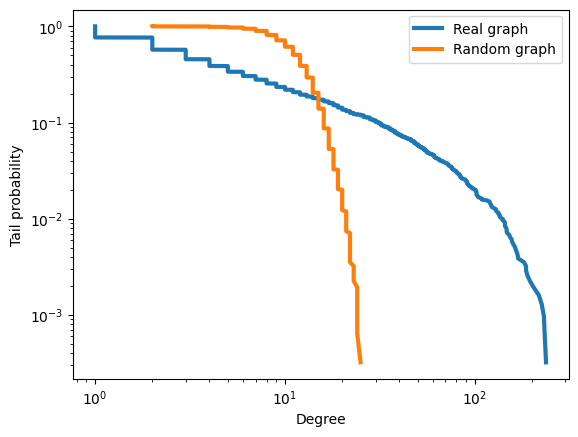

In [13]:
# Openflights: degree tail.
plot_loglog(get_degrees(openflights.adjacency))


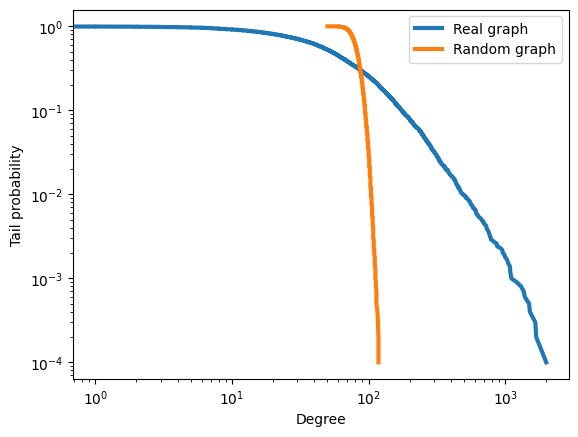

In [14]:
# WikiVitals: in-degree tail.
plot_loglog(get_degrees(wikivitals.adjacency, transpose=True))


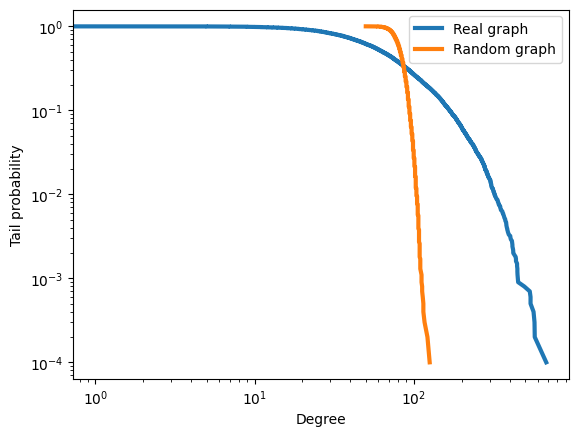

In [15]:
# WikiVitals: out-degree tail.
plot_loglog(get_degrees(wikivitals.adjacency))


**Conclusion.** The real tails are much heavier than the random-graph tails. They look broadly compatible with power-law behavior, especially compared with Erdos-Renyi graphs, although a visual log-log plot is not enough to prove an exact power law.

## 3. Small-world property

You will now make a few experiments highlighting the small-world property.

## To do

* Give a shortest path from [Plato](https://en.wikipedia.org/wiki/Plato) to [Platini](https://en.wikipedia.org/wiki/Michel_Platini) in WikiVitals.<br>
List the corresponding articles.

In [16]:
dataset = wikivitals
adjacency = dataset.adjacency
names = dataset.names

# Use the requested articles as source and target.
source = int(np.where(names == 'Plato')[0][0])
target = int(np.where(names == 'Michel Platini')[0][0])
adjacency_shortest_path = get_shortest_path(adjacency, source)


In [17]:
# Reconstruct the path backwards, then reverse it.
path = []
current_node = target
while current_node != source:
    path.append(current_node)
    current_node = int(get_neighbors(adjacency_shortest_path, current_node, transpose=True)[0])
path.append(source)
path = path[::-1]

names[path]


array(['Plato', 'Naples', 'Diego Maradona', 'Michel Platini'],
      dtype='<U62')

The shortest path found is: **Plato -> Naples -> Diego Maradona -> Michel Platini**.

## To do

* Which fraction of the airports can be reached from **Paris Charles de Gaulle** in 1, 2, 3 flights?
* Which fraction of the articles can be reached from **Paris** in 1, 2, 3 clicks on Wikipedia Vitals?

In [18]:
# Airports reachable from Paris Charles de Gaulle in at most 1, 2, 3 flights.
adjacency = openflights.adjacency
names = openflights.names
source = int(np.where(names == 'Charles de Gaulle International Airport')[0][0])
distances = get_distances(adjacency, source)

[(distances <= k).mean() for k in [1, 2, 3]]


[np.float64(0.07555699063609946),
 np.float64(0.6189861155957378),
 np.float64(0.9089441394898289)]

In [19]:
# Articles reachable from Paris in at most 1, 2, 3 clicks.
adjacency = wikivitals.adjacency
names = wikivitals.names
source = int(np.where(names == 'Paris')[0][0])
distances = get_distances(adjacency, source)

[(distances <= k).mean() for k in [1, 2, 3]]


[np.float64(0.0425531914893617),
 np.float64(0.6771551293577065),
 np.float64(0.9963040655279193)]

**Answer.** From Paris Charles de Gaulle, about `7.56%`, `61.90%`, and `90.89%` of airports are reachable in at most 1, 2, and 3 flights. From the Wikipedia article **Paris**, about `4.26%`, `67.72%`, and `99.63%` of articles are reachable in at most 1, 2, and 3 clicks.

## To do

* Compute the [Bacon number](https://fr.wikipedia.org/wiki/Six_Degrees_of_Kevin_Bacon) of all actors (**without** building the co-starring actor graph).
* Plot the corresponding histogram.

In [20]:
dataset = cinema
# Biadjacency matrix: rows are movies, columns are actors.
biadjacency = dataset.biadjacency
movies = dataset.names_row
actors = dataset.names_col

kevin = int(np.where(actors == 'Kevin Bacon')[0][0])

# Distances are computed on the bipartite graph directly.
# Actor-to-actor distances are even, so Bacon number = distance / 2.
_, actor_distances = get_distances(biadjacency, source_col=kevin)
bacon_numbers = actor_distances // 2
bacon_numbers[:10]


array([3, 3, 2, 3, 1, 2, 2, 3, 2, 3])

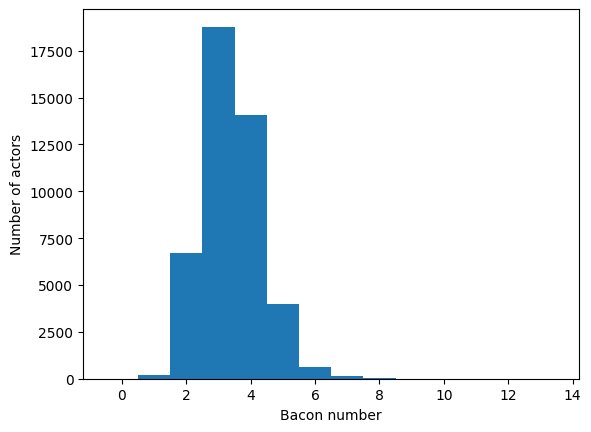

In [21]:
plt.hist(bacon_numbers, bins=np.arange(bacon_numbers.max() + 2) - 0.5)
plt.xlabel('Bacon number')
plt.ylabel('Number of actors')
plt.show()


Most actors are close to Kevin Bacon in this dataset: the largest Bacon number is `13`, and most actors have Bacon number between `2` and `4`.

## 4. Clustering coefficient

Finally, we check the clustering property of real graphs (my friends tend to be friends).

## To do


* Compute the clustering coefficient of Openflights.
* Compare with that of a random graph of same size and same average degree.

In [22]:
dataset = openflights
adjacency = dataset.adjacency


In [23]:
clustering = get_clustering_coefficient(adjacency)
clustering


np.float64(0.25107219520077)

In [24]:
n = adjacency.shape[0]
degrees = get_degrees(adjacency)

# Random graph with same size and same average degree.
p = degrees.mean() / (n - 1)
adjacency_random = erdos_renyi(n, p)
clustering_random = get_clustering_coefficient(adjacency_random)
clustering_random


np.float64(0.00338096483511258)

**Conclusion.** Openflights has clustering coefficient about `0.251`, while a comparable random graph is around `0.004`. The airport graph is therefore much more clustered than a random graph with the same size and average degree.